# NAVYA — Model Export and App-Compatible Inference Test

This notebook rebuilds and saves the complete final pipeline, writes model metadata, validates app payloads, and demonstrates the unchanged backend response contract. No backend source file is created.

## 1. Recreate the final pipeline and export it

The pipeline contains the training-fitted median imputer (and scaler when applicable) plus estimator. It is fitted on the 900 train-plus-validation women and saved as one joblib artifact.

In [1]:
from pathlib import Path
from datetime import date, datetime, timedelta
import json, joblib, numpy as np, pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
)
from sklearn.svm import SVR
from xgboost import XGBRegressor

ROOT = Path.cwd().resolve()
ROOT = ROOT if (ROOT / "data").exists() else ROOT.parent
FEATURES = [
    "age_years",
    "menarche_age",
    "height_cm",
    "weight_kg",
    "bmi",
    "sleep_hours",
    "stress_level",
    "exercise_frequency",
    "uses_medication_or_contraceptive",
    "prev_cycle_1",
    "prev_cycle_2",
    "prev_cycle_3",
    "avg_previous_cycle_length",
    "std_previous_cycle_length",
    "prev_period_1",
    "prev_period_2",
    "prev_period_3",
    "avg_previous_period_length",
]
df = pd.read_csv(ROOT / "processed_data" / "model_ready_dataset.csv")
women = np.random.RandomState(42).permutation(np.sort(df.woman_id.unique()))
train = df[df.woman_id.isin(women[:800])].copy()
with open(ROOT / "results" / "tuning" / "best_tuned_model.json") as f:
    selected = json.load(f)
assert selected["model"] == "XGBRegressor", "Run Notebook 05 first: export must use the locked XGBRegressor selection."


def make_pipeline(name, params):
    klass = {
        "GradientBoostingRegressor": GradientBoostingRegressor,
        "RandomForestRegressor": RandomForestRegressor,
        "XGBRegressor": XGBRegressor,
        "SVR": SVR,
    }[name]
    kw = {"random_state": 42}
    if name == "RandomForestRegressor":
        kw["n_jobs"] = -1
    if name == "XGBRegressor":
        kw.update({"objective": "reg:squarederror", "n_jobs": -1})
    kw.update({k.replace("model__", ""): v for k, v in params.items()})
    steps = [("imputer", SimpleImputer(strategy="median"))]
    if name == "SVR":
        steps.append(("scaler", StandardScaler()))
    return Pipeline(steps + [("model", klass(**kw))])


# Export the exact 800-woman pipeline used for conformal calibration and final test evaluation.
pipeline = joblib.load(ROOT / "models" / "calibrated_cycle_length_model.joblib")
assert pipeline.named_steps["model"].__class__.__name__ == selected["model"], (
    "Calibrated pipeline is stale. Re-run Notebook 08 before exporting."
)
models_dir = ROOT / "models"
models_dir.mkdir(exist_ok=True)
model_path = models_dir / "cycle_length_model.joblib"
joblib.dump(pipeline, model_path)
print("Saved:", model_path)

Saved: D:\PROJECT\New_Model_Train\models\cycle_length_model.joblib


## 2. Save explicit metadata

Metadata makes the preprocessing contract inspectable by the later backend integration: feature order, mappings, validation ranges, history fallbacks, model choice, and actual final test metrics.

In [2]:
with open(ROOT / "results" / "metrics" / "final_evaluation.json") as f:
    evaluation = json.load(f)
assert evaluation["selected_model"]["model"] == selected["model"], (
    "Final evaluation is stale. Re-run Notebook 09 before exporting."
)
cycle_history_median = float(
    train[["prev_cycle_1", "prev_cycle_2", "prev_cycle_3"]].stack().median()
)
period_history_median = float(
    train[["prev_period_1", "prev_period_2", "prev_period_3"]].stack().median()
)
metadata = {
    "model_version": "1.0.0",
    "training_date": date.today().isoformat(),
    "target": "next_cycle_length_days",
    "feature_names": FEATURES,
    "feature_order": FEATURES,
    "selected_estimator": selected["model"],
    "hyperparameters": selected["best_params"],
    "final_test_metrics": evaluation["final_test_metrics"],
    "training_cycle_history_median": cycle_history_median,
    "training_period_history_median": period_history_median,
    "categorical_mappings": {
        "stress": {"Very Low": 1, "Low": 2, "Moderate": 3, "High": 4, "Very High": 5},
        "exercise": {
            "Never": 0,
            "1-2 days/week": 1,
            "3-4 days/week": 2,
            "5+ days/week": 2,
        },
        "medication_or_contraceptive": {"No": 0, "Yes": 1, "Not Sure": "NaN"},
    },
    "uncertainty_method": evaluation["uncertainty"]["method"],
    "coverage": evaluation["uncertainty"]["nominal_coverage"],
    "q_hat_days": evaluation["uncertainty"]["q_hat_days"],
    "supported_cycle_lower_bound": evaluation["uncertainty"]["supported_cycle_lower_bound"],
    "supported_cycle_upper_bound": evaluation["uncertainty"]["supported_cycle_upper_bound"],
    "height_conversion_rule": "feet = floor(height); inches = round((height - feet) * 10); height_cm = (feet * 12 + inches) * 2.54; bmi = weight_kg / (height_cm / 100)^2",
    "validation_ranges": {
        "age_years": [8, 100],
        "menarche_age": "7 through age_years",
        "height_cm": [100, 230],
        "weight_kg": [25, 250],
        "sleep_hours": [1, 24],
        "stress_level": "integer 1 through 5",
        "exercise_frequency": "integer 0 through 2",
        "previous_cycle_length": [15, 60],
        "previous_period_length": [1, 14],
    },
}
metadata_path = models_dir / "cycle_length_model_metadata.json"
metadata_path.write_text(json.dumps(metadata, indent=2))
display(pd.DataFrame({"position": range(1, 19), "feature": FEATURES}))
print("Saved:", metadata_path)

,position,feature
0,1,age_years
1,2,menarche_age
2,3,height_cm
3,4,weight_kg
4,5,bmi
5,6,sleep_hours
6,7,stress_level
7,8,exercise_frequency
8,9,uses_medication_or_contraceptive
9,10,prev_cycle_1


Saved: D:\PROJECT\New_Model_Train\models\cycle_length_model_metadata.json


## 3. App payload validation and feature construction

These notebook-local functions reject malformed or impossible inputs with clear errors. Incomplete histories are padded with the available mean; empty histories use training-history medians. The resulting DataFrame is explicitly placed in the exact 18-feature order.

In [3]:
def require_number(name, value, low, high, integer=False):
    if (
        isinstance(value, bool)
        or not isinstance(value, (int, float, np.integer, np.floating))
        or not np.isfinite(value)
    ):
        raise ValueError(f"{name} must be a finite number.")
    if integer and int(value) != value:
        raise ValueError(f"{name} must be an integer.")
    if not low <= value <= high:
        raise ValueError(f"{name} must be between {low} and {high}.")
    return int(value) if integer else float(value)


def normalise_history(name, values, low, high, empty_median):
    if not isinstance(values, list):
        raise ValueError(f"{name} must be a list.")
    if len(values) > 3:
        raise ValueError(f"{name} may contain at most 3 values.")
    vals = [require_number(f"{name}[{i}]", v, low, high) for i, v in enumerate(values)]
    if not vals:
        return [empty_median] * 3
    return vals + [float(np.mean(vals))] * (3 - len(vals))


def build_features(payload, today=None):
    required = {
        "date_of_birth",
        "menarche_age",
        "height_cm",
        "weight_kg",
        "sleep_hours",
        "stress_level",
        "exercise_frequency",
        "uses_medication_or_contraceptive",
        "cycle_lengths",
        "period_lengths",
    }
    missing = required - set(payload)
    if missing:
        raise ValueError(f"Missing required fields: {sorted(missing)}")
    try:
        dob = datetime.strptime(payload["date_of_birth"], "%Y-%m-%d").date()
    except (TypeError, ValueError):
        raise ValueError("date_of_birth must be YYYY-MM-DD.")
    today = today or date.today()
    age = today.year - dob.year - ((today.month, today.day) < (dob.month, dob.day))
    require_number("age_years", age, 8, 100, True)
    menarche = require_number("menarche_age", payload["menarche_age"], 7, age, True)
    h = require_number("height_cm", payload["height_cm"], 100, 230)
    w = require_number("weight_kg", payload["weight_kg"], 25, 250)
    sleep = require_number("sleep_hours", payload["sleep_hours"], 1, 24)
    stress = require_number("stress_level", payload["stress_level"], 1, 5, True)
    exercise = require_number(
        "exercise_frequency", payload["exercise_frequency"], 0, 2, True
    )
    medication = payload["uses_medication_or_contraceptive"]
    if not isinstance(medication, bool):
        raise ValueError("uses_medication_or_contraceptive must be boolean.")
    cycles = normalise_history(
        "cycle_lengths", payload["cycle_lengths"], 15, 60, cycle_history_median
    )
    periods = normalise_history(
        "period_lengths", payload["period_lengths"], 1, 14, period_history_median
    )
    row = {
        "age_years": age,
        "menarche_age": menarche,
        "height_cm": h,
        "weight_kg": w,
        "bmi": w / (h / 100) ** 2,
        "sleep_hours": sleep,
        "stress_level": stress,
        "exercise_frequency": exercise,
        "uses_medication_or_contraceptive": int(medication),
        "prev_cycle_1": cycles[0],
        "prev_cycle_2": cycles[1],
        "prev_cycle_3": cycles[2],
        "avg_previous_cycle_length": float(np.mean(cycles)),
        "std_previous_cycle_length": float(np.std(cycles, ddof=0)),
        "prev_period_1": periods[0],
        "prev_period_2": periods[1],
        "prev_period_3": periods[2],
        "avg_previous_period_length": float(np.mean(periods)),
    }
    return pd.DataFrame([[row[c] for c in FEATURES]], columns=FEATURES)


def predict_cycle(payload):
    x = build_features(payload)
    raw = float(joblib.load(model_path).predict(x)[0])
    clamped = float(np.clip(raw, 15, 60))
    return {
        "raw_prediction": raw,
        "rounded_prediction": round(clamped),
        "clamped_prediction": clamped,
        "features": x,
    }


example = {
    "date_of_birth": "2000-08-15",
    "menarche_age": 13,
    "height_cm": 165.1,
    "weight_kg": 60.0,
    "sleep_hours": 6,
    "stress_level": 3,
    "exercise_frequency": 1,
    "uses_medication_or_contraceptive": False,
    "cycle_lengths": [28, 29, 27],
    "period_lengths": [5, 5, 6],
}
demo = predict_cycle(example)
print({k: v for k, v in demo.items() if k != "features"})
display(demo["features"])

{'raw_prediction': 28.01360511779785, 'rounded_prediction': 28, 'clamped_prediction': 28.01360511779785}


,age_years,menarche_age,height_cm,weight_kg,bmi,sleep_hours,stress_level,exercise_frequency,uses_medication_or_contraceptive,prev_cycle_1,prev_cycle_2,prev_cycle_3,avg_previous_cycle_length,std_previous_cycle_length,prev_period_1,prev_period_2,prev_period_3,avg_previous_period_length
0,26,13,165.1,60.0,22.011878,6.0,3,1,0,28.0,29.0,27.0,28.0,0.816497,5.0,5.0,6.0,5.333333


## 4. Backend response simulation

This demonstration preserves the existing response field names. Period length is deliberately not predicted by this ML model: it is the mean of available prior period lengths, or 5 when none are available. Phase values stay lowercase.

In [4]:
def backend_response(payload, last_period_start, today=None):
    today = today or date.today()
    try:
        last = datetime.strptime(last_period_start, "%Y-%m-%d").date()
    except (TypeError, ValueError):
        raise ValueError("last_period_start must be YYYY-MM-DD.")
    if last > today:
        raise ValueError("last_period_start cannot be in the future.")
    prediction = predict_cycle(payload)
    rounded = prediction["rounded_prediction"]
    available = payload["period_lengths"]
    period = float(np.mean(available)) if available else 5.0
    expected = last + timedelta(days=rounded)
    days = max(0, (expected - today).days)
    cycle_day = (today - last).days + 1
    if cycle_day <= period:
        phase = "menstrual"
    elif cycle_day <= 13:
        phase = "follicular"
    elif cycle_day <= 16:
        phase = "ovulation"
    else:
        phase = "luteal"
    return {
        "predicted_cycle_length_days": prediction["clamped_prediction"],
        "predicted_period_length_days": period,
        "last_period_start": last.isoformat(),
        "next_expected_period": expected.isoformat(),
        "days_until_period": days,
        "cycle_day": cycle_day,
        "phase": phase,
    }


response = backend_response(example, "2026-07-01", today=date(2026, 7, 26))
display(response)
for bad in [
    dict(example, stress_level=6),
    dict(example, cycle_lengths=[10]),
    dict(example, date_of_birth="not-a-date"),
]:
    try:
        predict_cycle(bad)
    except ValueError as e:
        print("Validation error:", e)

{'predicted_cycle_length_days': 28.01360511779785,
 'predicted_period_length_days': 5.333333333333333,
 'last_period_start': '2026-07-01',
 'next_expected_period': '2026-07-29',
 'days_until_period': 3,
 'cycle_day': 26,
 'phase': 'luteal'}

Validation error: stress_level must be between 1 and 5.
Validation error: cycle_lengths[0] must be between 15 and 60.
Validation error: date_of_birth must be YYYY-MM-DD.


## 5. Visualise the inference result and cycle timeline

Cycle history is supplied oldest-to-newest, then reversed for the feature contract: `prev_cycle_1` is the most recently completed cycle. Users with fewer than three cycles receive a clearly labelled history-based fallback. For three cycles, the model first checks the 1st–99th percentile training support range; supported histories receive a 90% split-conformal interval, while clearly unsupported histories receive a history-average fallback. Menstrual cycle length naturally varies, so this avoids false precision and prevents blind use of the ML model outside its represented data.

Oldest→newest input: [53, 56, 58]  | Model fields prev_cycle_1..3: [58, 56, 53]


,predicted_cycle_length_days,prediction_method,prediction_status,prediction_interval,model_feature_order_check
normal_three_cycles,28.013605,machine_learning,supported,"{'lower_days': 25.840620040893555, 'upper_days...",True
longer_supported_history,30.779158,machine_learning,supported,"{'lower_days': 28.606172561645508, 'upper_days...",True
extreme_history,55.666667,fallback_history_average,outside_training_distribution,NaN,NaN
one_cycle,28.0,fallback_history_average,not_enough_cycle_history,NaN,NaN
two_cycles,29.0,fallback_history_average,not_enough_cycle_history,NaN,NaN


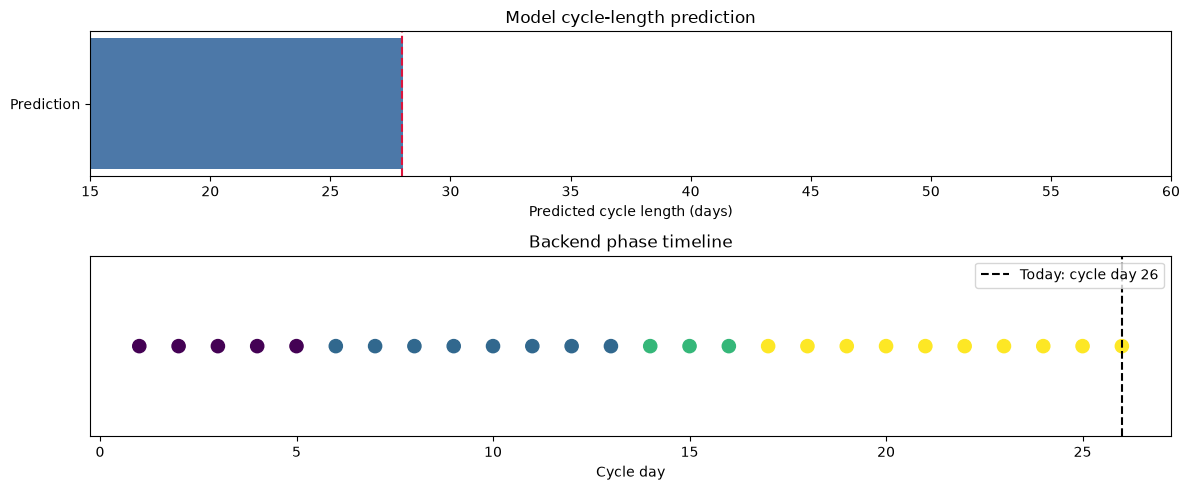

In [ ]:
# Definitive deployment policy: cycle_lengths are supplied oldest-to-newest.
# The newest three are reversed for the trained feature contract: prev_cycle_1, prev_cycle_2, prev_cycle_3.
def validated_cycle_history(values):
    if not isinstance(values, list):
        raise ValueError("cycle_lengths must be a list ordered oldest-to-newest.")
    return [
        require_number(f"cycle_lengths[{i}]", value, 15, 60)
        for i, value in enumerate(values)
    ]


def predict_with_uncertainty(payload):
    cycles = validated_cycle_history(payload.get("cycle_lengths", []))
    if len(cycles) == 0:
        return {
            "predicted_cycle_length_days": cycle_history_median,
            "prediction_method": "fallback_population_median",
            "prediction_status": "not_enough_personal_data",
        }
    if len(cycles) < 3:
        return {
            "predicted_cycle_length_days": float(np.mean(cycles)),
            "prediction_method": "fallback_history_average",
            "prediction_status": "not_enough_cycle_history",
        }
    recent_oldest_to_newest = cycles[-3:]
    if (
        min(recent_oldest_to_newest) < metadata["supported_cycle_lower_bound"]
        or max(recent_oldest_to_newest) > metadata["supported_cycle_upper_bound"]
    ):
        return {
            "predicted_cycle_length_days": float(np.mean(recent_oldest_to_newest)),
            "prediction_method": "fallback_history_average",
            "prediction_status": "outside_training_distribution",
        }
    model_payload = dict(payload)
    model_payload["cycle_lengths"] = list(reversed(recent_oldest_to_newest))
    features = build_features(model_payload)
    prediction = float(np.clip(joblib.load(model_path).predict(features)[0], 15, 60))
    q_hat = float(metadata["q_hat_days"])
    return {
        "predicted_cycle_length_days": prediction,
        "prediction_method": "machine_learning",
        "prediction_status": "supported",
        "prediction_interval": {
            "lower_days": max(15, prediction - q_hat),
            "upper_days": min(60, prediction + q_hat),
            "coverage": metadata["coverage"],
        },
        "model_feature_order_check": features.columns.tolist() == FEATURES,
    }


# Ordering example: app sends oldest→newest [53, 56, 58]; model would receive [58, 56, 53].
ordering_example = [53, 56, 58]
print(
    "Oldest→newest input:",
    ordering_example,
    " | Model fields prev_cycle_1..3:",
    list(reversed(ordering_example[-3:])),
)


def backend_response(payload, last_period_start, today=None):
    today = today or date.today()
    last = datetime.strptime(last_period_start, "%Y-%m-%d").date()
    result = predict_with_uncertainty(payload)
    rounded_cycle = round(result["predicted_cycle_length_days"])
    period_values = payload.get("period_lengths", [])
    predicted_period = float(np.mean(period_values)) if period_values else 5.0
    expected = last + timedelta(days=rounded_cycle)
    cycle_day = (today - last).days + 1
    phase = (
        "menstrual"
        if cycle_day <= predicted_period
        else (
            "follicular"
            if cycle_day <= 13
            else "ovulation" if cycle_day <= 16 else "luteal"
        )
    )
    return {
        **result,
        "predicted_period_length_days": predicted_period,
        "last_period_start": last.isoformat(),
        "next_expected_period": expected.isoformat(),
        "days_until_period": max(0, (expected - today).days),
        "cycle_day": cycle_day,
        "phase": phase,
    }


normal_case = dict(example, cycle_lengths=[27, 29, 28])
case_results = {
    "normal_three_cycles": predict_with_uncertainty(normal_case),
    "longer_supported_history": predict_with_uncertainty(
        dict(example, cycle_lengths=[30, 32, 31])
    ),
    "extreme_history": predict_with_uncertainty(
        dict(example, cycle_lengths=[53, 56, 58])
    ),
    "one_cycle": predict_with_uncertainty(dict(example, cycle_lengths=[28])),
    "two_cycles": predict_with_uncertainty(dict(example, cycle_lengths=[28, 30])),
}
display(pd.DataFrame(case_results).T)
response = backend_response(normal_case, "2026-07-01", today=date(2026, 7, 26))
import matplotlib.pyplot as plt
import seaborn as sns

cycle_days = np.arange(1, response["cycle_day"] + 1)


def phase_for_day(day, period_days):
    if day <= period_days:
        return "menstrual"
    if day <= 13:
        return "follicular"
    if day <= 16:
        return "ovulation"
    return "luteal"


phase_series = [
    phase_for_day(day, response["predicted_period_length_days"]) for day in cycle_days
]
phase_codes = pd.Categorical(
    phase_series, categories=["menstrual", "follicular", "ovulation", "luteal"]
).codes
fig, axes = plt.subplots(
    2, 1, figsize=(12, 5), gridspec_kw={"height_ratios": [1, 1.25]}
)
axes[0].barh(["Prediction"], [response["predicted_cycle_length_days"]], color="#4C78A8")
axes[0].axvline(
    (
        response["rounded_cycle_length_days"]
        if "rounded_cycle_length_days" in response
        else round(response["predicted_cycle_length_days"])
    ),
    color="crimson",
    linestyle="--",
)
axes[0].set(
    xlabel="Predicted cycle length (days)", title="Model cycle-length prediction"
)
axes[0].set_xlim(15, 60)
axes[1].scatter(
    cycle_days, np.ones_like(cycle_days), c=phase_codes, cmap="viridis", s=90
)
axes[1].axvline(
    response["cycle_day"],
    color="black",
    linestyle="--",
    label=f"Today: cycle day {response['cycle_day']}",
)
axes[1].set(yticks=[], xlabel="Cycle day", title="Backend phase timeline")
axes[1].legend(loc="upper right")
plt.tight_layout()
plt.show()

## Observation

`cycle_length_model.joblib` is self-contained for preprocessing and prediction. The metadata documents the exact feature order, uncertainty rule, and all app-side construction rules; API integration remains intentionally outside this notebook project.